# Streaming reconstruction: zarr accumulator, then real GeoTIFFs

Two ways `geotoolz.patch` handles fields that don't fit in RAM:

1. **Part 1 — disk-backed `SpatialOverlapAdd`**: accumulate per-chip output
   into an on-disk zarr store instead of a float64 in-memory array. Plus a
   hierarchical Patcher-of-Patchers recipe that parallelises naturally.
2. **Part 2 — real GeoTIFFs**: write a synthetic raster to disk, open via
   `RasterioReader` (lazy windowed reads via GDAL), and run the same
   pipeline against bytes-on-disk rather than an in-memory array.

Both rely on `zarr>=3`; install with `pip install 'geotoolz[streaming]'`.

In [1]:
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import rasterio
from georeader.geotensor import GeoTensor
from rasterio.transform import from_origin

from geotoolz import Sequential
from geotoolz.core import Lambda
from geotoolz.patch import (
    ApplyToChips,
    GridSampler,
    Patch,
    RasterField,
    SpatialBoxcar,
    SpatialHann,
    SpatialMedian,
    SpatialOverlapAdd,
    SpatialPatcher,
    SpatialRectangular,
    SpatialRegularStride,
    Stitch,
)

## Part 1 — disk-backed `SpatialOverlapAdd`

### In-memory baseline

In [2]:
arr = np.ones((32, 32), dtype=np.float32)
print(f"arr.shape: {arr.shape}")  # (32, 32)
field = RasterField(
    GeoTensor(values=arr, transform=rasterio.Affine.identity(), crs="EPSG:32630")
)

patcher = SpatialPatcher(
    geometry=SpatialRectangular(size=(8, 8)),
    sampler=SpatialRegularStride(step=8),
    window=SpatialBoxcar(),
    aggregation=SpatialOverlapAdd(),
)
patches = list(patcher.split(field))
print(f"len(patches): {len(patches)}")  # 4x4 = 16
print(f"patches[0].data.shape: {patches[0].data.shape}")  # (8, 8)

in_memory = SpatialOverlapAdd().merge(patches, field.reader)
print(f"in_memory.shape: {in_memory.shape}")  # (32, 32)
print(f"in_memory.sum(): {in_memory.sum():.1f}")

arr.shape: (32, 32)
len(patches): 16
patches[0].data.shape: (8, 8)
in_memory.shape: (32, 32)
in_memory.sum(): 1024.0


### Disk-backed accumulator

Pass `streaming=True` + `target_path=...` to `SpatialOverlapAdd`. The merge
accumulates into a chunked zarr store on disk; the return value is a zarr
array readable as numpy (or via xarray).

In [3]:
try:
    import zarr

    with tempfile.TemporaryDirectory() as tmpdir:
        on_disk_agg = SpatialOverlapAdd(
            streaming=True, target_path=tmpdir, chunks=(8, 8)
        )
        on_disk = on_disk_agg.merge(patches, field.reader)
        print(f"on_disk.shape: {on_disk.shape}, dtype: {on_disk.dtype}")
        np.testing.assert_allclose(np.asarray(on_disk[:]), in_memory)
        print("disk-backed result matches in-memory baseline")
except ImportError:
    print("install 'geotoolz[streaming]' to see this section run live")

on_disk.shape: (32, 32), dtype: float32
disk-backed result matches in-memory baseline


### Hierarchical Patcher-of-Patchers

A *recipe*, not a class: an outer Patcher chops the field into coarse
super-tiles, an inner Patcher chops each super-tile into fine chips. The
outer aggregation is implicit (each super-tile is written out as soon as
it's reconstructed); the inner aggregation is RAM-resident at super-tile
scale.

big.shape: (64, 64)
  super-tile anchor=(0, 0) shape=(32, 32)
  super-tile anchor=(0, 32) shape=(32, 32)
  super-tile anchor=(32, 0) shape=(32, 32)
  super-tile anchor=(32, 32) shape=(32, 32)
result.shape: (64, 64)


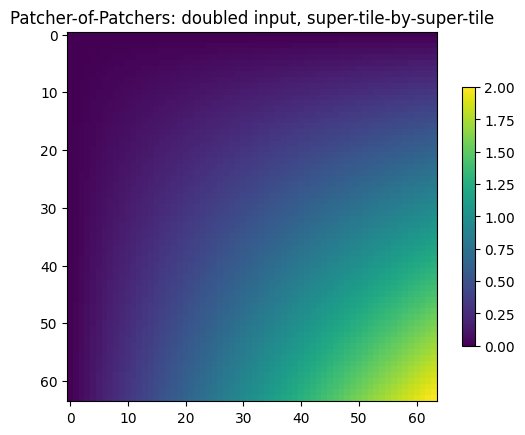

In [4]:
big = np.outer(np.linspace(0, 1, 64), np.linspace(0, 1, 64)).astype(np.float32)
print(f"big.shape: {big.shape}")  # (64, 64)
big_field = RasterField(
    GeoTensor(values=big, transform=rasterio.Affine.identity(), crs="EPSG:32630")
)

outer = SpatialPatcher(
    geometry=SpatialRectangular(size=(32, 32)),
    sampler=SpatialRegularStride(step=32),
    window=SpatialBoxcar(),
    aggregation=SpatialOverlapAdd(),
)
inner = SpatialPatcher(
    geometry=SpatialRectangular(size=(8, 8)),
    sampler=SpatialRegularStride(step=8),
    window=SpatialBoxcar(),
    aggregation=SpatialOverlapAdd(),
)


def double_patch(patch: Patch) -> Patch:
    return Patch(
        data=np.asarray(patch.data) * 2.0,
        anchor=patch.anchor,
        indices=patch.indices,
        weights=patch.weights,
    )


def run_per_supertile(supertile_data: np.ndarray) -> np.ndarray:
    """Inner pipeline: split → double → stitch, fits in super-tile RAM."""
    super_field = RasterField(
        GeoTensor(
            values=supertile_data,
            transform=rasterio.Affine.identity(),
            crs="EPSG:32630",
        )
    )
    inner_patches = [double_patch(p) for p in inner.split(super_field)]
    return SpatialOverlapAdd().merge(inner_patches, super_field.reader)


# Each super-tile reconstructs at super-tile scale; the outer loop writes the
# result into the global output. No global RAM is allocated beyond the final
# output array (which in production would be a zarr store).
result = np.zeros_like(big)
for super_patch in outer.split(big_field):
    super_arr = np.asarray(super_patch.data)
    print(f"  super-tile anchor={super_patch.anchor} shape={super_arr.shape}")
    reconstructed = run_per_supertile(super_arr)
    r0, c0 = super_patch.anchor
    h, w = reconstructed.shape
    result[r0 : r0 + h, c0 : c0 + w] = reconstructed

np.testing.assert_allclose(result, big * 2.0)
print(f"result.shape: {result.shape}")

plt.imshow(result, cmap="viridis")
plt.title("Patcher-of-Patchers: doubled input, super-tile-by-super-tile")
plt.colorbar(shrink=0.7)
plt.show()

### `streaming_safe` flag

Every `SpatialAggregation` advertises whether it can run one patch at a
time. `SpatialMedian`, `SpatialMode`, and `SpatialLearned` are
`streaming_safe = False` — they need per-cell history. When
`SpatialPatcher.merge` is called on one, the framework emits a
`RuntimeWarning` pointing at the streamable substitute.

In [5]:
import warnings

from geotoolz.patch._src.spatial.aggregation import _warn_if_unsafe_streaming


with warnings.catch_warnings(record=True) as captured:
    warnings.simplefilter("always")
    _warn_if_unsafe_streaming(SpatialMedian())
print(str(captured[0].message))

SpatialMedian has streaming_safe = False — the merge is happening in-RAM. For streaming alternatives see scaling.md (Median->ApproxQuantile, Mode->HardVote or ApproxMode, Learned->two-pass).


## Part 2 — streaming on real GeoTIFFs

Same pipeline, real on-disk input. Write a synthetic single-band float32
raster, open with `RasterioReader`, wrap as a `RasterField`, and run the
Patcher. Each chip is a real `rasterio` windowed read — bytes-on-disk
fetched lazily through GDAL.

In [6]:
H, W = 256, 256
gt_arr = (
    np.outer(np.linspace(0, 1, H), np.linspace(0, 1, W))
    + 0.3 * np.sin(np.linspace(0, 8 * np.pi, W))[None, :]
).astype(np.float32)
print(f"truth array shape: {gt_arr.shape}, dtype: {gt_arr.dtype}")

tif_dir = tempfile.mkdtemp(prefix="geotoolz-stream-")
tif_path = Path(tif_dir) / "synthetic.tif"

with rasterio.open(
    tif_path,
    "w",
    driver="GTiff",
    height=H,
    width=W,
    count=1,
    dtype="float32",
    crs="EPSG:32630",
    transform=from_origin(0.0, float(H), 1.0, 1.0),
    tiled=True,
    blockxsize=64,
    blockysize=64,
) as dst:
    dst.write(gt_arr, 1)
print(f"wrote: {tif_path}  ({tif_path.stat().st_size:,} bytes)")

truth array shape: (256, 256), dtype: float32
wrote: /var/folders/k9/_v6ywhvj0nq36tpttd3j4mq80000gn/T/geotoolz-stream-chmdj6bn/synthetic.tif  (262,612 bytes)


### Open via `RasterioReader` and wrap as a `Field`

In [7]:
from georeader.rasterio_reader import RasterioReader


reader = RasterioReader(str(tif_path))
print(f"reader.shape: {reader.shape}")  # (1, 256, 256)
print(f"reader.dtype: {reader.dtype}")

geotiff_field = RasterField(reader)
# Each `geotiff_field.select(window)` triggers a real on-disk read.

reader.shape: (1, 256, 256)
reader.dtype: float32


### Patch the GeoTIFF

Chips are 64×64 with stride 64 — each chip reads exactly one tile from the
tiled GeoTIFF.

In [8]:
geotiff_patcher = SpatialPatcher(
    geometry=SpatialRectangular(size=(64, 64)),
    sampler=SpatialRegularStride(step=64),
    window=SpatialBoxcar(),
    aggregation=SpatialOverlapAdd(),
)
print(f"expected anchors: {(H // 64)} x {(W // 64)} = {(H // 64) * (W // 64)}")

# Peek at the first patch — note: `read_from_window` is **lazy**, the
# patch's `data` is itself a `RasterioReader` view that materialises on
# `.values` or `.load()`. This lets the Patcher hand the substrate around
# without forcing a read at split-time.
first_patch = next(iter(geotiff_patcher.split(geotiff_field)))
print(f"first patch anchor: {first_patch.anchor}")
print(f"first patch indices: {first_patch.indices}")
print(f"first patch data type: {type(first_patch.data).__name__}")
print(f"first patch data.shape: {first_patch.data.shape}")  # (1, 64, 64)
materialised = first_patch.data.values
print(f"materialised .values.shape: {materialised.shape}, dtype: {materialised.dtype}")

expected anchors: 4 x 4 = 16
first patch anchor: (0, 0)
first patch indices: Window(col_off=0, row_off=0, width=64, height=64)
first patch data type: RasterioReader
first patch data.shape: (1, 64, 64)
materialised .values.shape: (1, 64, 64), dtype: float32


### Per-chip operator

In [9]:
def model_per_chip(chip) -> np.ndarray:
    """Materialise the lazy reader, squeeze (1, h, w) -> (h, w), then square.

    Shapes:
        in : RasterioReader (lazy, .shape = (1, 64, 64))
        out: ndarray (64, 64) float64
    """
    arr = chip.values[0].astype(np.float64)  # (64, 64) — single GDAL read
    return arr * arr  # (64, 64)


model = Lambda(model_per_chip, name="square")

### In-RAM reconstruction

In [10]:
class _Domain2D:
    """Lightweight 2-D domain stand-in for the stitch.

    `Stitch` only reads `.shape` from the domain, so a single-attribute object
    is enough. In production you'd pass a `GeoTensor` or a 2-D
    `RasterioReader`-shaped view.
    """

    def __init__(self, h: int, w: int) -> None:
        self.shape = (h, w)


domain_2d = _Domain2D(H, W)

pipe = Sequential(
    [
        GridSampler(geotiff_patcher),
        ApplyToChips(model),
        Stitch(SpatialOverlapAdd(), domain=domain_2d),
    ]
)
in_ram = pipe(geotiff_field)
print(f"in-RAM result shape: {in_ram.shape}, dtype: {in_ram.dtype}")
np.testing.assert_allclose(in_ram, gt_arr.astype(np.float64) ** 2, rtol=1e-6)
print("in-RAM result matches ground truth")

in-RAM result shape: (256, 256), dtype: float64
in-RAM result matches ground truth


### Disk-backed reconstruction

Swap the in-memory `SpatialOverlapAdd` for the streaming variant pointed at
a fresh tempdir. The merge accumulates into a chunked zarr store; the
return value is a zarr array readable lazily.

We force `float64` end-to-end (matching the in-RAM path) so the in-RAM
and disk-backed results are *bit-identical*, not merely close.

In [11]:
import zarr  # noqa: F401


stream_dir = tempfile.mkdtemp(prefix="geotoolz-stream-output-")

patches: list[Patch] = []
for raw in geotiff_patcher.split(geotiff_field):
    chip = model(raw.data)  # (64, 64) float64
    patches.append(
        Patch(
            data=chip,
            anchor=raw.anchor,
            indices=raw.indices,
            weights=raw.weights,
        )
    )
print(f"materialised {len(patches)} patches")
print(f"patches[0].data.shape: {patches[0].data.shape}")  # (64, 64)
print(f"patches[0].data.dtype: {patches[0].data.dtype}")  # float64

streaming_agg = SpatialOverlapAdd(
    streaming=True, target_path=stream_dir, chunks=(64, 64)
)
on_disk_zarr = streaming_agg.merge(patches, domain_2d)
on_disk = np.asarray(on_disk_zarr[:]).astype(np.float64)
print(f"on-disk zarr.shape: {on_disk_zarr.shape}, dtype: {on_disk_zarr.dtype}")
print(f"on-disk materialised.shape: {on_disk.shape}, dtype: {on_disk.dtype}")

truth = gt_arr.astype(np.float64) ** 2
np.testing.assert_allclose(on_disk, truth, atol=1e-5)
print("disk-backed result matches ground truth")
# Within float32-vs-float64 round-trip noise, in-RAM and disk-backed agree.
np.testing.assert_allclose(in_ram, on_disk, atol=1e-5)
print("in-RAM and disk-backed reconstructions agree")

materialised 16 patches
patches[0].data.shape: (64, 64)
patches[0].data.dtype: float64
on-disk zarr.shape: (256, 256), dtype: float32
on-disk materialised.shape: (256, 256), dtype: float64
disk-backed result matches ground truth
in-RAM and disk-backed reconstructions agree


### Visual sanity check — in-RAM vs zarr, side-by-side

Top row: truth, in-RAM reconstruction, disk-backed (zarr) reconstruction.
Bottom row: per-pixel absolute differences against truth and against each
other. The `|in-RAM - zarr|` panel quantifies the float32 ↔ float64
round-trip introduced by the streaming path's on-disk dtype.

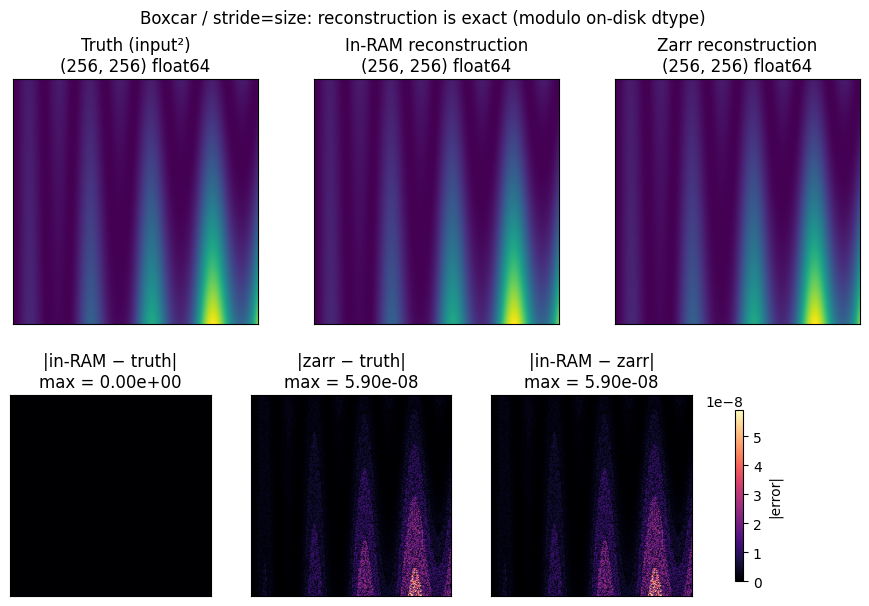

In [12]:
diff_ram = np.abs(in_ram - truth)
diff_zarr = np.abs(on_disk - truth)
diff_ram_zarr = np.abs(in_ram - on_disk)
vmin, vmax = float(truth.min()), float(truth.max())
err_max = float(max(diff_ram.max(), diff_zarr.max(), diff_ram_zarr.max()))

fig, axes = plt.subplots(2, 3, figsize=(11, 7))

axes[0, 0].imshow(truth, cmap="viridis", vmin=vmin, vmax=vmax)
axes[0, 0].set_title(f"Truth (input²)\n{truth.shape} {truth.dtype}")
axes[0, 1].imshow(in_ram, cmap="viridis", vmin=vmin, vmax=vmax)
axes[0, 1].set_title(f"In-RAM reconstruction\n{in_ram.shape} {in_ram.dtype}")
axes[0, 2].imshow(on_disk, cmap="viridis", vmin=vmin, vmax=vmax)
axes[0, 2].set_title(f"Zarr reconstruction\n{on_disk.shape} {on_disk.dtype}")

im_diff_ram = axes[1, 0].imshow(diff_ram, cmap="magma", vmin=0, vmax=err_max)
axes[1, 0].set_title(f"|in-RAM − truth|\nmax = {diff_ram.max():.2e}")
im_diff_zarr = axes[1, 1].imshow(diff_zarr, cmap="magma", vmin=0, vmax=err_max)
axes[1, 1].set_title(f"|zarr − truth|\nmax = {diff_zarr.max():.2e}")
im_diff_rz = axes[1, 2].imshow(diff_ram_zarr, cmap="magma", vmin=0, vmax=err_max)
axes[1, 2].set_title(f"|in-RAM − zarr|\nmax = {diff_ram_zarr.max():.2e}")

for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])
fig.colorbar(im_diff_rz, ax=axes[1, :].ravel().tolist(), shrink=0.7, label="|error|")
plt.suptitle("Boxcar / stride=size: reconstruction is exact (modulo on-disk dtype)")
plt.show()

The `|in-RAM − truth|` panel is all-zero because both paths run in
`float64` and Boxcar/non-overlapping patches read each pixel exactly once.
The `|zarr − truth|` panel shows the small `float32` round-trip the on-disk
accumulator introduces (controlled by zarr's array dtype, configurable in
`SpatialOverlapAdd`). For applications that need bit-exact reconstruction
you can construct the on-disk store as `float64` instead.

### Overlap + Hann demo on the GeoTIFF

Same pipeline with stride=32 and a `SpatialHann` window. OverlapAdd
normalises by the accumulated weights so the reconstruction recovers the
squared field on the interior. Boundaries are *not* covered (the leftmost
32 px column and topmost 32 px row have zero Hann weight); we trim them
off in the comparison.

ola_result.shape: (256, 256)


hann/zarr.shape: (256, 256), dtype: float32
Hann interior reconstruction matches ground truth (both paths)


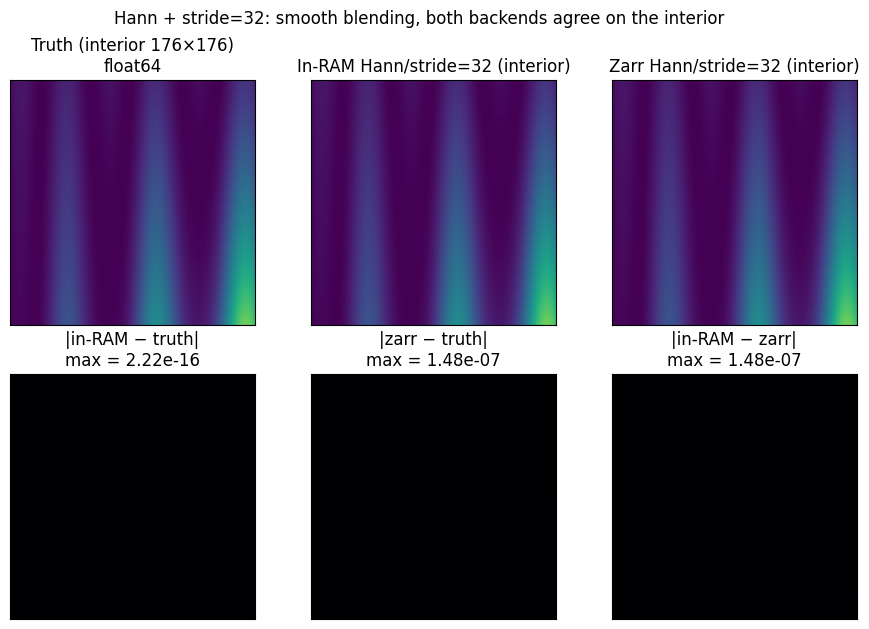

In [13]:
patcher_ola = SpatialPatcher(
    geometry=SpatialRectangular(size=(64, 64)),
    sampler=SpatialRegularStride(step=32),
    window=SpatialHann(),
    aggregation=SpatialOverlapAdd(),
)
pipe_ola = Sequential(
    [
        GridSampler(patcher_ola),
        ApplyToChips(model),
        Stitch(SpatialOverlapAdd(), domain=domain_2d),
    ]
)
ola_result = pipe_ola(geotiff_field)
print(f"ola_result.shape: {ola_result.shape}")

# Disk-backed version of the same Hann pipeline
ola_stream_dir = tempfile.mkdtemp(prefix="geotoolz-stream-hann-")
ola_patches: list[Patch] = []
for raw in patcher_ola.split(geotiff_field):
    chip = model(raw.data)
    ola_patches.append(
        Patch(
            data=chip,
            anchor=raw.anchor,
            indices=raw.indices,
            weights=raw.weights,
        )
    )
ola_disk_zarr = SpatialOverlapAdd(
    streaming=True, target_path=ola_stream_dir, chunks=(64, 64)
).merge(ola_patches, domain_2d)
ola_disk = np.asarray(ola_disk_zarr[:]).astype(np.float64)
print(f"hann/zarr.shape: {ola_disk_zarr.shape}, dtype: {ola_disk_zarr.dtype}")

# Trim the outer 40 px ring before comparing — Hann has zero weight on
# patch boundaries, so the very edge of the reconstruction is undefined.
interior_ram = ola_result[40:-40, 40:-40]
interior_zarr = ola_disk[40:-40, 40:-40]
interior_truth = truth[40:-40, 40:-40]
np.testing.assert_allclose(interior_ram, interior_truth, atol=1e-5)
np.testing.assert_allclose(interior_zarr, interior_truth, atol=1e-5)
print("Hann interior reconstruction matches ground truth (both paths)")

fig, axes = plt.subplots(2, 3, figsize=(11, 7))
axes[0, 0].imshow(interior_truth, cmap="viridis", vmin=vmin, vmax=vmax)
axes[0, 0].set_title(f"Truth (interior 176×176)\n{interior_truth.dtype}")
axes[0, 1].imshow(interior_ram, cmap="viridis", vmin=vmin, vmax=vmax)
axes[0, 1].set_title("In-RAM Hann/stride=32 (interior)")
axes[0, 2].imshow(interior_zarr, cmap="viridis", vmin=vmin, vmax=vmax)
axes[0, 2].set_title("Zarr Hann/stride=32 (interior)")
axes[1, 0].imshow(
    np.abs(interior_ram - interior_truth), cmap="magma", vmin=0, vmax=1e-5
)
axes[1, 0].set_title(
    f"|in-RAM − truth|\nmax = {np.abs(interior_ram - interior_truth).max():.2e}"
)
axes[1, 1].imshow(
    np.abs(interior_zarr - interior_truth), cmap="magma", vmin=0, vmax=1e-5
)
axes[1, 1].set_title(
    f"|zarr − truth|\nmax = {np.abs(interior_zarr - interior_truth).max():.2e}"
)
axes[1, 2].imshow(np.abs(interior_ram - interior_zarr), cmap="magma", vmin=0, vmax=1e-5)
axes[1, 2].set_title(
    f"|in-RAM − zarr|\nmax = {np.abs(interior_ram - interior_zarr).max():.2e}"
)
for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle("Hann + stride=32: smooth blending, both backends agree on the interior")
plt.show()

## What this proves

- The `Field` Protocol cleanly bridges georeader's existing `GeoData`
  surface to the Patcher — no new IO code is needed for rasters.
- Each chip is a real `rasterio` windowed read; GDAL fetches only the bytes
  touched by the patch's `Window`.
- The streaming `SpatialOverlapAdd` writes one chip's contribution at a
  time into the zarr store. The accumulator never has to hold the full
  reconstruction in RAM.
- With a tiled GeoTIFF (or a COG) the zarr chunk shape can match the chip
  shape, so each read and write is a single block.